# Instalasi dan Inisialisasi Environment

In [1]:
# ── Install dependency ────────────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'boto3', 'imbalanced-learn', '-q'], check=True)
print('✅ Dependencies siap')

# ── Konfigurasi MinIO ─────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

MINIO_ENDPOINT   = 'http://minio-kelompok3:9000'
MINIO_ACCESS_KEY = 'minioadmin'
MINIO_SECRET_KEY = 'minioadmin'

GOLD_PATH   = 's3a://datalake/processed/gold/hr-attrition/ml_features_csv/'
SILVER_PATH = 's3a://datalake/processed/silver/hr-attrition/'

spark = (
    SparkSession.builder
    .appName('HR-Attrition-Analitik')
    .config('spark.jars.packages',
            'org.apache.hadoop:hadoop-aws:3.3.4,'
            'com.amazonaws:aws-java-sdk-bundle:1.12.262')
    .config('spark.hadoop.fs.s3a.endpoint',               MINIO_ENDPOINT)
    .config('spark.hadoop.fs.s3a.access.key',             MINIO_ACCESS_KEY)
    .config('spark.hadoop.fs.s3a.secret.key',             MINIO_SECRET_KEY)
    .config('spark.hadoop.fs.s3a.path.style.access',      'true')
    .config('spark.hadoop.fs.s3a.impl',
            'org.apache.hadoop.fs.s3a.S3AFileSystem')
    .config('spark.hadoop.fs.s3a.connection.ssl.enabled', 'false')
    .config('spark.sql.shuffle.partitions',               '2')
    .config('spark.driver.memory',                        '512m')
    .config('spark.executor.memory',                      '512m')
    .config('spark.driver.maxResultSize',                 '256m')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print(f'✅ SparkSession aktif | Spark {spark.version}')

✅ Dependencies siap
✅ SparkSession aktif | Spark 3.5.0


# Load Data dari MinIO (Gold & Silver Layer)

In [2]:
# ════════════════════════════════════════════════════════════════
# Baca Gold & Silver langsung dari MinIO — TIDAK ada baca CSV lokal
# ════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import ast
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql.functions import col, udf
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col as F_col

# ── Baca Gold dari MinIO (Parquet) ────────────────────────────────────────
df_gold = spark.read.option('header', 'true').option('inferSchema', 'true').csv(GOLD_PATH)

# ── Baca Silver dari MinIO (Parquet) ─────────────────────────────────────
df_silver = spark.read.parquet(SILVER_PATH)

print(f'✅ Gold  : {df_gold.count()} baris, kolom: {df_gold.columns}')
print(f'✅ Silver: {df_silver.count()} baris')
df_gold.printSchema()

✅ Gold  : 1470 baris, kolom: ['scaled_features', 'Department_index', 'JobRole_index', 'Gender_index', 'OverTime_index', 'left_company']
✅ Silver: 1470 baris
root
 |-- scaled_features: string (nullable = true)
 |-- Department_index: double (nullable = true)
 |-- JobRole_index: double (nullable = true)
 |-- Gender_index: double (nullable = true)
 |-- OverTime_index: double (nullable = true)
 |-- left_company: integer (nullable = true)



# Setup — Parse Features & Feature Assembly

In [3]:
# ════════════════════════════════════════════════════════════════
# STEP 1: Handle sparse vector di kolom scaled_features
#         Parquet dari Spark mungkin menyimpan sebagai SparseVector
#         → convert ke DenseVector
# ════════════════════════════════════════════════════════════════
from pyspark.ml.linalg import Vectors, VectorUDT, SparseVector, DenseVector
from pyspark.sql.functions import udf as spark_udf

def to_dense_vector(v):
    if v is None:
        return None
    if isinstance(v, SparseVector):
        return Vectors.dense(v.toArray())
    if isinstance(v, DenseVector):
        return v
    # fallback: coba parse string jika ada
    try:
        s = str(v).strip()
        if s.startswith('('):
            parts = ast.literal_eval(s)
            size, indices, values = int(parts[0]), list(parts[1]), list(parts[2])
            arr = np.zeros(size)
            for i, val in zip(indices, values):
                arr[i] = val
            return Vectors.dense(arr)
        parsed = ast.literal_eval(s)
        return Vectors.dense([float(x) for x in parsed])
    except:
        return None

to_dense_udf = spark_udf(to_dense_vector, VectorUDT())

# Terapkan konversi
df_gold = df_gold.withColumn('scaled_features', to_dense_udf(col('scaled_features')))
df_gold = df_gold.filter(col('scaled_features').isNotNull())

print(f'✅ DenseVector siap: {df_gold.count()} baris valid')

# ════════════════════════════════════════════════════════════════
# STEP 2: Cast kolom index & label
# ════════════════════════════════════════════════════════════════
df = df_gold     .withColumn('Department_index', col('Department_index').cast('double'))     .withColumn('JobRole_index',    col('JobRole_index').cast('double'))     .withColumn('Gender_index',     col('Gender_index').cast('double'))     .withColumn('OverTime_index',   col('OverTime_index').cast('double'))     .withColumn('left_company',     col('left_company').cast('int'))

# ════════════════════════════════════════════════════════════════
# STEP 3: Expand scaled_features → kolom terpisah
# ════════════════════════════════════════════════════════════════
df = df.withColumn('feat_arr', vector_to_array('scaled_features'))

feature_names = [
    'Age_scaled', 'MonthlyIncome_scaled', 'JobSatisfaction_scaled',
    'PerformanceRating_scaled', 'WorkLifeBalance_scaled', 'YearsAtCompany_scaled'
]
for i, name in enumerate(feature_names):
    df = df.withColumn(name, F_col('feat_arr')[i])

# ════════════════════════════════════════════════════════════════
# STEP 4: Assemble feature vector final
# ════════════════════════════════════════════════════════════════
all_feature_cols = feature_names + [
    'Department_index', 'JobRole_index', 'Gender_index', 'OverTime_index'
]

assembler = VectorAssembler(inputCols=all_feature_cols, outputCol='features')
df_model = assembler.transform(df).select('features', 'left_company')
df_model.cache()

# df_raw untuk EDA (kolom lengkap, belum di-assemble)
df_raw = df

print(f'✅ Feature vector siap | Jumlah fitur: {len(all_feature_cols)}')
print(f'   Fitur: {all_feature_cols}')
print(f'   Total baris: {df_model.count()}')
df_model.show(3, truncate=80)

✅ DenseVector siap: 1470 baris valid
✅ Feature vector siap | Jumlah fitur: 10
   Fitur: ['Age_scaled', 'MonthlyIncome_scaled', 'JobSatisfaction_scaled', 'PerformanceRating_scaled', 'WorkLifeBalance_scaled', 'YearsAtCompany_scaled', 'Department_index', 'JobRole_index', 'Gender_index', 'OverTime_index']
   Total baris: 1470
+--------------------------------------------------------------------------------+------------+
|                                                                        features|left_company|
+--------------------------------------------------------------------------------+------------+
|[0.738095238095238,0.21700895208004214,0.3333333333333333,1.0,0.6666666666666...|           0|
|[0.38095238095238093,0.08699315429173249,1.0,0.0,0.6666666666666666,0.05,0.0,...|           0|
|[0.09523809523809523,0.1014218009478673,1.0,0.0,0.3333333333333333,0.025,0.0,...|           0|
+--------------------------------------------------------------------------------+------------+
only

# Exploratory Data Analysis (EDA)

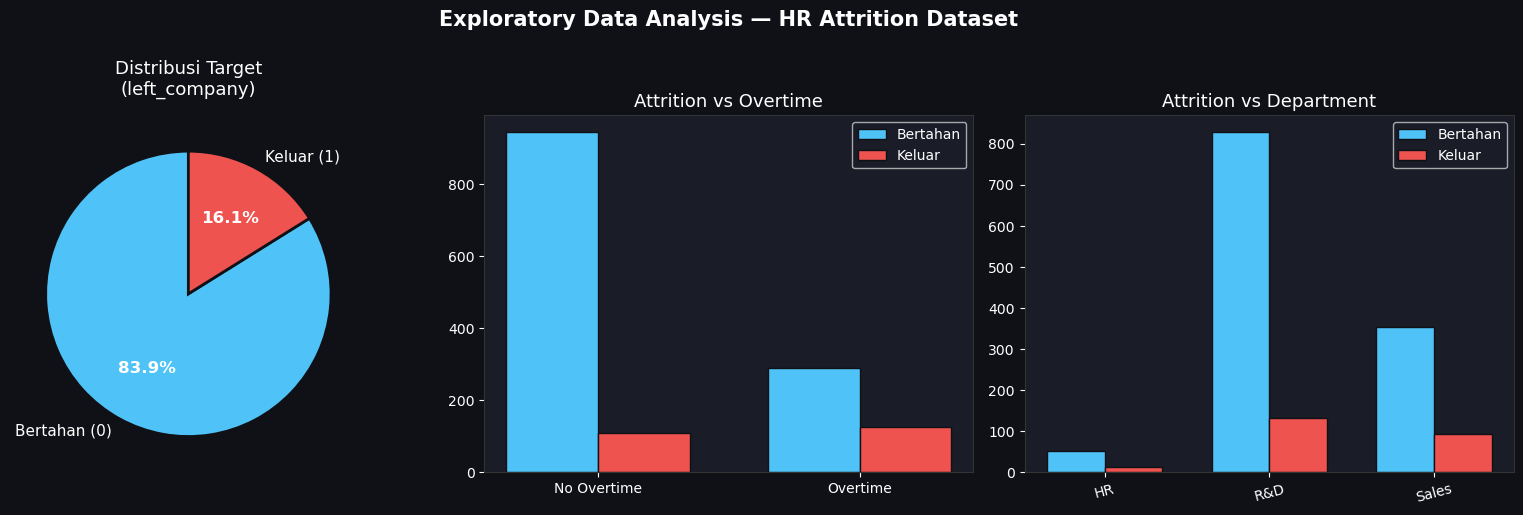


Class distribution:
left_company
0    1233
1     237
Name: count, dtype: int64
Imbalance ratio: 5.2:1


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Gunakan df_raw (kolom masih terpisah, aman di-collect)
df_pd = df_raw.select(
    'left_company', 'OverTime_index', 'Department_index',
    'Age_scaled', 'MonthlyIncome_scaled', 'JobSatisfaction_scaled',
    'WorkLifeBalance_scaled', 'YearsAtCompany_scaled'
).toPandas()

# ── 1. Distribusi Target ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d27')

labels = ['Bertahan (0)', 'Keluar (1)']
sizes  = df_pd['left_company'].value_counts().sort_index().values
colors = ['#4fc3f7', '#ef5350']
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2),
    textprops=dict(color='white', fontsize=11)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[0].set_title('Distribusi Target\n(left_company)', color='white', fontsize=13, pad=15)

ot_labels = {0: 'No Overtime', 1: 'Overtime'}
df_pd['OverTime_label'] = df_pd['OverTime_index'].map(ot_labels)
ct = df_pd.groupby(['OverTime_label', 'left_company']).size().unstack(fill_value=0)
x = np.arange(len(ct.index))
w = 0.35
axes[1].bar(x - w/2, ct[0], w, label='Bertahan', color='#4fc3f7', edgecolor='#0f1117')
axes[1].bar(x + w/2, ct[1], w, label='Keluar',   color='#ef5350', edgecolor='#0f1117')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ct.index, color='white')
axes[1].set_title('Attrition vs Overtime', color='white', fontsize=13)
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#333')

dept_labels = {0.0: 'R&D', 1.0: 'Sales', 2.0: 'HR'}
df_pd['Dept_label'] = df_pd['Department_index'].map(dept_labels).fillna('Other')
ct2 = df_pd.groupby(['Dept_label', 'left_company']).size().unstack(fill_value=0)
x2 = np.arange(len(ct2.index))
axes[2].bar(x2 - w/2, ct2[0], w, label='Bertahan', color='#4fc3f7', edgecolor='#0f1117')
axes[2].bar(x2 + w/2, ct2[1], w, label='Keluar',   color='#ef5350', edgecolor='#0f1117')
axes[2].set_xticks(x2)
axes[2].set_xticklabels(ct2.index, color='white', rotation=15)
axes[2].set_title('Attrition vs Department', color='white', fontsize=13)
axes[2].tick_params(colors='white')
axes[2].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[2].spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('Exploratory Data Analysis — HR Attrition Dataset',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f"\nClass distribution:\n{df_pd['left_company'].value_counts()}")
print(f"Imbalance ratio: {df_pd['left_company'].value_counts()[0]/df_pd['left_company'].value_counts()[1]:.1f}:1")

# Analisis Class Imbalance & Penanganan dengan SMOTE

## Latar Belakang
Dataset HR Attrition memiliki distribusi kelas yang **tidak seimbang (imbalanced)**. 
Kelas mayoritas (Bertahan/0) jauh lebih banyak daripada kelas minoritas (Keluar/1).
Hal ini menyebabkan model cenderung bias ke mayoritas, sehingga akurasi terlihat tinggi 
padahal kemampuan mendeteksi karyawan yang akan keluar (Recall kelas 1) sangat rendah.

**Solusi:** SMOTE (Synthetic Minority Oversampling Technique) — membuat data sintetis baru 
untuk kelas minoritas dengan cara interpolasi antar tetangga terdekat (K-NN), sehingga 
distribusi kelas menjadi seimbang sebelum training.

  📊 ANALISIS CLASS IMBALANCE
  Bertahan (0) :  1233 (83.9%)
  Keluar   (1) :   237 (16.1%)
  Rasio Imbalance : 5.2:1
  ⚠️  Dataset TIDAK SEIMBANG — perlu penanganan SMOTE

✅ Dataset split: train=1216, test=254

Distribusi training sebelum SMOTE: {0: 1022, 1: 194}
Distribusi training sesudah SMOTE : {0: 1022, 1: 1022}
Jumlah sampel sintetis ditambahkan: 828

✅ SMOTE selesai — data training baru: 2044 baris
   (test_data tetap menggunakan data asli tanpa SMOTE)


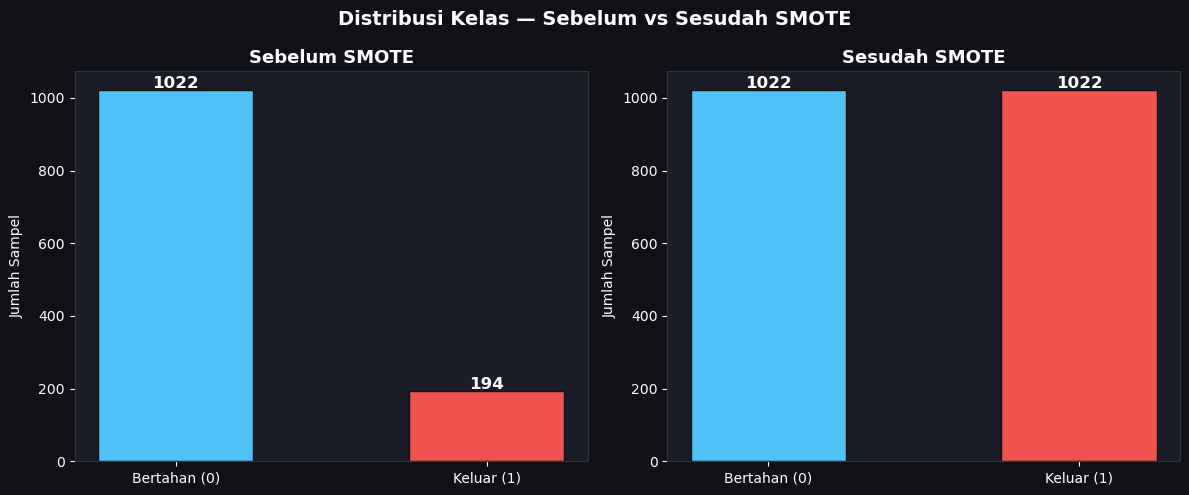

✅ Visualisasi SMOTE disimpan: smote_distribution.png


In [5]:
# ════════════════════════════════════════════════════════════════
# ANALISIS CLASS IMBALANCE & PENANGANAN DENGAN SMOTE
# CATATAN: SMOTE HANYA diterapkan pada data training, BUKAN test set
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from pyspark.ml.linalg import Vectors
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col as F_col
from collections import Counter
from pyspark.sql import Row

# ── Step 1: Cek distribusi kelas ──────────────────────────────────────────
print("=" * 55)
print("  📊 ANALISIS CLASS IMBALANCE")
print("=" * 55)
df_pd_check = df_model.toPandas()
label_counts = df_pd_check['left_company'].value_counts().sort_index()
total = len(df_pd_check)
print(f"  Bertahan (0) : {label_counts[0]:>5} ({label_counts[0]/total*100:.1f}%)")
print(f"  Keluar   (1) : {label_counts[1]:>5} ({label_counts[1]/total*100:.1f}%)")
print(f"  Rasio Imbalance : {label_counts[0]/label_counts[1]:.1f}:1")
print("=" * 55)
if label_counts[0]/label_counts[1] > 1.5:
    print("  ⚠️  Dataset TIDAK SEIMBANG — perlu penanganan SMOTE")
else:
    print("  ✅  Dataset cukup seimbang")

# ── Step 2: Split data dulu (SMOTE hanya di training!) ────────────────────
train_spark, test_spark = df_model.randomSplit([0.8, 0.2], seed=42)
print(f"\n✅ Dataset split: train={train_spark.count()}, test={test_spark.count()}")

# ── Step 3: Konversi training ke Pandas untuk SMOTE ──────────────────────
train_pd = train_spark.select(
    vector_to_array("features").alias("feat"), "left_company"
).toPandas()

X_train = np.array(train_pd['feat'].tolist())
y_train = train_pd['left_company'].values
print(f"\nDistribusi training sebelum SMOTE: {dict(Counter(y_train))}")

# ── Step 4: Terapkan SMOTE ────────────────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
print(f"Distribusi training sesudah SMOTE : {dict(Counter(y_resampled))}")
print(f"Jumlah sampel sintetis ditambahkan: {len(X_resampled) - len(X_train)}")

# ── Step 5: Konversi balik ke Spark DataFrame ─────────────────────────────
rows = [
    Row(features=Vectors.dense(X_resampled[i].tolist()), left_company=int(y_resampled[i]))
    for i in range(len(y_resampled))
]
train_data = spark.createDataFrame(rows)
train_data.cache()
test_data = test_spark  # test set TIDAK di-SMOTE

print(f"\n✅ SMOTE selesai — data training baru: {train_data.count()} baris")
print("   (test_data tetap menggunakan data asli tanpa SMOTE)")

# ── Step 6: Visualisasi sebelum vs sesudah ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d27')

before = dict(Counter(y_train))
after  = dict(Counter(y_resampled))
labels_bar = ['Bertahan (0)', 'Keluar (1)']
colors_bar = ['#4fc3f7', '#ef5350']

axes[0].bar(labels_bar, [before[0], before[1]], color=colors_bar, edgecolor='#0f1117', width=0.5)
for i, v in enumerate([before[0], before[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', color='white', fontsize=12, fontweight='bold')
axes[0].set_title('Sebelum SMOTE', color='white', fontsize=13, fontweight='bold')
axes[0].tick_params(colors='white')
axes[0].set_ylabel('Jumlah Sampel', color='white')
for sp in axes[0].spines.values(): sp.set_edgecolor('#333')

axes[1].bar(labels_bar, [after[0], after[1]], color=colors_bar, edgecolor='#0f1117', width=0.5)
for i, v in enumerate([after[0], after[1]]):
    axes[1].text(i, v + 5, str(v), ha='center', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('Sesudah SMOTE', color='white', fontsize=13, fontweight='bold')
axes[1].tick_params(colors='white')
axes[1].set_ylabel('Jumlah Sampel', color='white')
for sp in axes[1].spines.values(): sp.set_edgecolor('#333')

plt.suptitle('Distribusi Kelas — Sebelum vs Sesudah SMOTE', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Visualisasi SMOTE disimpan: smote_distribution.png")

# Train Test Split (80:20)

In [6]:
# ════════════════════════════════════════════════════════════════
# CATATAN: Split 80:20 sudah dilakukan di cell SMOTE di atas.
# Variabel train_data dan test_data sudah tersedia (post-SMOTE).
# Cell ini hanya menampilkan statistik distribusi untuk referensi.
# ════════════════════════════════════════════════════════════════
print("✅ Referensi split dataset (train_data = setelah SMOTE, test_data = asli)")
print(f"   Training set : {train_data.count()} baris (sudah di-SMOTE)")
print(f"   Testing set  : {test_data.count()} baris (data asli)")

print("\nDistribusi train (setelah SMOTE):")
train_data.groupBy("left_company").count().show()
print("Distribusi test (data asli):")
test_data.groupBy("left_company").count().show()

✅ Referensi split dataset (train_data = setelah SMOTE, test_data = asli)
   Training set : 2044 baris (sudah di-SMOTE)
   Testing set  : 254 baris (data asli)

Distribusi train (setelah SMOTE):
+------------+-----+
|left_company|count|
+------------+-----+
|           0| 1022|
|           1| 1022|
+------------+-----+

Distribusi test (data asli):
+------------+-----+
|left_company|count|
+------------+-----+
|           0|  211|
|           1|   43|
+------------+-----+



# Model 1 (Random Forest Classifier)

In [7]:
# ── Pastikan SMOTE sudah dijalankan ───────────────────────────────────────
try:
    train_count = train_data.count()
    test_count  = test_data.count()
    dist = train_data.groupBy("left_company").count().collect()
    dist_dict = {r['left_company']: r['count'] for r in dist}
    ratio = dist_dict.get(0, 0) / max(dist_dict.get(1, 1), 1)
    if ratio > 1.5:
        print("⚠️  PERINGATAN: train_data masih tidak seimbang!")
        print(f"   Rasio: {ratio:.1f}:1 — pastikan cell SMOTE sudah dijalankan")
    else:
        print(f"✅ train_data seimbang (rasio {ratio:.2f}:1) — SMOTE sudah diterapkan")
    print(f"   train={train_count} baris | test={test_count} baris")
except NameError:
    raise RuntimeError("❌ Jalankan cell 'Analisis Class Imbalance & SMOTE' terlebih dahulu!")

from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="left_company",
    numTrees=100,
    maxDepth=5,
    seed=42
)

print("⏳ Melatih Random Forest... (100 trees)")
rf_model = rf.fit(train_data)
print("✅ Training selesai!")

rf_pred = rf_model.transform(test_data)
rf_pred.select("left_company", "prediction", "probability").show(10)

✅ train_data seimbang (rasio 1.00:1) — SMOTE sudah diterapkan
   train=2044 baris | test=254 baris
⏳ Melatih Random Forest... (100 trees)
✅ Training selesai!
+------------+----------+--------------------+
|left_company|prediction|         probability|
+------------+----------+--------------------+
|           0|       0.0|[0.67332931974595...|
|           0|       0.0|[0.62286366862753...|
|           0|       0.0|[0.70827369338508...|
|           1|       0.0|[0.64058396225549...|
|           0|       0.0|[0.62502346829759...|
|           0|       0.0|[0.82153921789836...|
|           1|       0.0|[0.70699971258789...|
|           0|       0.0|[0.65897243031285...|
|           1|       0.0|[0.74348253364155...|
|           0|       0.0|[0.73795887682148...|
+------------+----------+--------------------+
only showing top 10 rows



# Evaluasi Random Forest

In [8]:
bin_eval = BinaryClassificationEvaluator(labelCol="left_company", rawPredictionCol="rawPrediction")
mc_eval  = MulticlassClassificationEvaluator(labelCol="left_company", predictionCol="prediction")

rf_auc       = bin_eval.evaluate(rf_pred)
rf_precision = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "weightedPrecision"})
rf_recall    = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "weightedRecall"})
rf_f1        = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "f1"})
rf_acc       = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "accuracy"})

print("=" * 45)
print("  📊 EVALUASI RANDOM FOREST CLASSIFIER")
print("=" * 45)
print(f"  AUC-ROC   : {rf_auc:.4f}")
print(f"  Accuracy  : {rf_acc:.4f}")
print(f"  Precision : {rf_precision:.4f}")
print(f"  Recall    : {rf_recall:.4f}")
print(f"  F1-Score  : {rf_f1:.4f}")
print("=" * 45)

rf_metrics = {
    "Model": "Random Forest",
    "AUC-ROC": rf_auc, "Accuracy": rf_acc,
    "Precision": rf_precision, "Recall": rf_recall, "F1-Score": rf_f1
}

  📊 EVALUASI RANDOM FOREST CLASSIFIER
  AUC-ROC   : 0.7802
  Accuracy  : 0.8031
  Precision : 0.8253
  Recall    : 0.8031
  F1-Score  : 0.8123


# Feature Importance

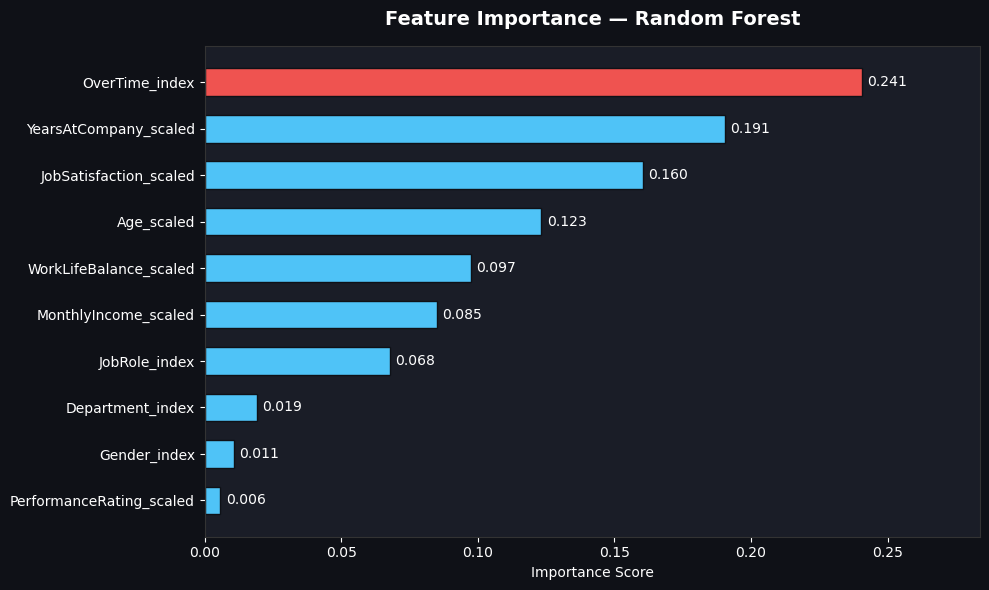

In [9]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf_model.featureImportances.toArray()
fi_df = sorted(zip(all_feature_cols, importances), key=lambda x: x[1], reverse=True)
names, vals = zip(*fi_df)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

colors_bar = ['#ef5350' if v == max(vals) else '#4fc3f7' for v in vals]
bars = ax.barh(names[::-1], vals[::-1], color=colors_bar[::-1], edgecolor='#0f1117', height=0.6)
for bar, val in zip(bars, vals[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=10)

ax.set_title('Feature Importance — Random Forest', color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.set_xlim(0, max(vals) * 1.18)

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Feature Selection Berdasarkan Feature Importance

Berdasarkan hasil Feature Importance dari Random Forest, dilakukan seleksi fitur 
untuk memastikan model hanya menggunakan fitur yang paling relevan secara statistik 
maupun secara logika bisnis HR. Fitur dengan kontribusi rendah (< threshold) 
dikeluarkan untuk mencegah noise dan overfitting.

  📊 FEATURE IMPORTANCE — RANKING LENGKAP
  Rank  Fitur                          Importance
  -----------------------------------------------
  1     OverTime_index                     0.2405 ✅
  2     YearsAtCompany_scaled              0.1905 ✅
  3     JobSatisfaction_scaled             0.1603 ✅
  4     Age_scaled                         0.1233 ✅
  5     WorkLifeBalance_scaled             0.0973 ✅
  6     MonthlyIncome_scaled               0.0850 ✅
  7     JobRole_index                      0.0678 ✅
  8     Department_index                   0.0190 ❌
  9     Gender_index                       0.0107 ❌
  10    PerformanceRating_scaled           0.0057 ❌
  -----------------------------------------------
  ✅ = dipilih (importance >= 0.05)
  ❌ = dibuang

✅ Fitur terpilih (7): ['OverTime_index', 'YearsAtCompany_scaled', 'JobSatisfaction_scaled', 'Age_scaled', 'WorkLifeBalance_scaled', 'MonthlyIncome_scaled', 'JobRole_index']
❌ Fitur dibuang  (3): ['Department_index', 'Gender_index', 'Perfor

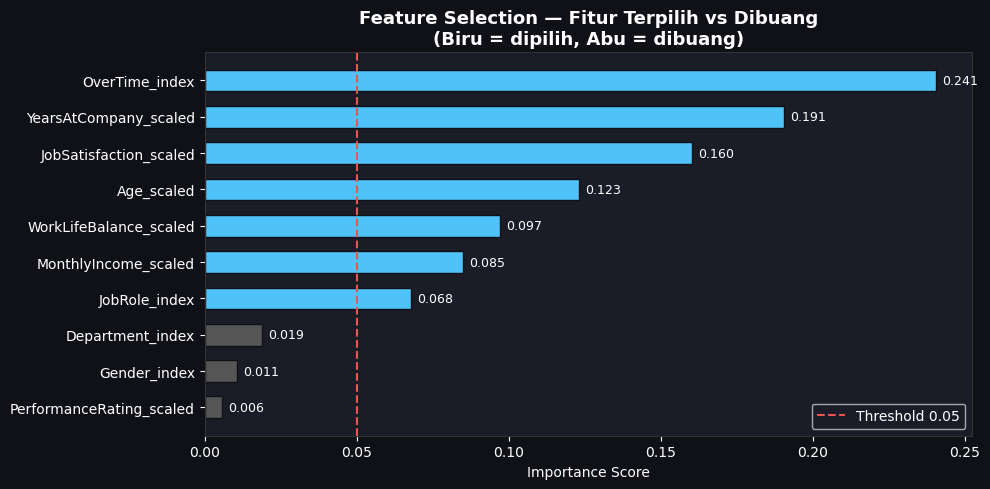

✅ Visualisasi Feature Selection disimpan: feature_selection.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from pyspark.ml.linalg import Vectors
from pyspark.ml.functions import vector_to_array
from collections import Counter
from pyspark.sql import Row

# ── Ambil importance dari RF model ────────────────────────────────────────
importances = rf_model.featureImportances.toArray()
fi_df = pd.DataFrame({
    'feature': all_feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("=" * 55)
print("  📊 FEATURE IMPORTANCE — RANKING LENGKAP")
print("=" * 55)
print(f"  {'Rank':<5} {'Fitur':<30} {'Importance':>10}")
print("  " + "-" * 47)
for i, row in fi_df.iterrows():
    marker = " ✅" if row['importance'] >= 0.05 else " ❌"
    print(f"  {i+1:<5} {row['feature']:<30} {row['importance']:>10.4f}{marker}")
print("  " + "-" * 47)
print("  ✅ = dipilih (importance >= 0.05)")
print("  ❌ = dibuang")
print("=" * 55)

IMPORTANCE_THRESHOLD = 0.05
selected_features = fi_df[fi_df['importance'] >= IMPORTANCE_THRESHOLD]['feature'].tolist()
dropped_features   = fi_df[fi_df['importance'] <  IMPORTANCE_THRESHOLD]['feature'].tolist()

print(f"\n✅ Fitur terpilih ({len(selected_features)}): {selected_features}")
print(f"❌ Fitur dibuang  ({len(dropped_features)}): {dropped_features}")

feature_desc = {
    'MonthlyIncome_scaled'      : 'Gaji — penyebab utama resign karena ketidakpuasan kompensasi',
    'Age_scaled'                : 'Usia — karyawan muda lebih mobile, senior lebih stabil',
    'YearsAtCompany_scaled'     : 'Masa kerja — loyalitas meningkat seiring lama bekerja',
    'JobSatisfaction_scaled'    : 'Kepuasan kerja — langsung berhubungan dengan keputusan resign',
    'WorkLifeBalance_scaled'    : 'Work-life balance — burnout mendorong attrition',
    'OverTime_index'            : 'Overtime — beban kerja berlebihan = risiko keluar tinggi',
    'JobRole_index'             : 'Role — job role tertentu memiliki turnover lebih tinggi',
    'Department_index'          : 'Departemen — pola attrition berbeda tiap divisi',
    'PerformanceRating_scaled'  : 'Performa — employee dengan rating rendah berisiko di-PHK',
    'Gender_index'              : 'Gender — untuk memastikan model tidak bias gender',
}
print("\n📌 Justifikasi Bisnis Fitur Terpilih:")
for f in selected_features:
    desc = feature_desc.get(f, 'Relevan berdasarkan analisis statistik')
    print(f"   • {f:<30} → {desc}")

# ── Rebuild feature vector dengan fitur terpilih ─────────────────────────
from pyspark.ml.feature import VectorAssembler

assembler_selected = VectorAssembler(inputCols=selected_features, outputCol="features_selected")
df_selected = assembler_selected.transform(df).select(
    F_col("features_selected").alias("features"), "left_company"
)
df_selected.cache()

train_selected_spark, test_selected_spark = df_selected.randomSplit([0.8, 0.2], seed=42)

# SMOTE ulang dengan fitur terpilih
train_sel_pd = train_selected_spark.select(
    vector_to_array("features").alias("feat"), "left_company"
).toPandas()

X_sel = np.array(train_sel_pd['feat'].tolist())
y_sel = train_sel_pd['left_company'].values

smote2 = SMOTE(random_state=42, k_neighbors=5)
X_sel_res, y_sel_res = smote2.fit_resample(X_sel, y_sel)

rows_sel = [
    Row(features=Vectors.dense(X_sel_res[i].tolist()), left_company=int(y_sel_res[i]))
    for i in range(len(y_sel_res))
]
train_data_selected = spark.createDataFrame(rows_sel)
train_data_selected.cache()
test_data_selected = test_selected_spark

print(f"\n✅ Dataset dengan fitur terpilih siap")
print(f"   Jumlah fitur: {len(all_feature_cols)} → {len(selected_features)}")
print(f"   Training (setelah SMOTE): {train_data_selected.count()} baris")
print(f"   Testing (asli)          : {test_data_selected.count()} baris")

# ── Visualisasi ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

bar_colors = ['#4fc3f7' if f in selected_features else '#555' for f in fi_df['feature']]
bars = ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
               color=bar_colors[::-1], edgecolor='#0f1117', height=0.6)
ax.axvline(x=IMPORTANCE_THRESHOLD, color='#ef5350', linestyle='--', linewidth=1.5, label=f'Threshold {IMPORTANCE_THRESHOLD}')
for bar, val in zip(bars, fi_df['importance'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=9)
ax.set_xlabel('Importance Score', color='white')
ax.set_title('Feature Selection — Fitur Terpilih vs Dibuang\n(Biru = dipilih, Abu = dibuang)',
             color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1d27', labelcolor='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333')
plt.tight_layout()
plt.savefig('feature_selection.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Visualisasi Feature Selection disimpan: feature_selection.png")

# Model 2 Logistic Regression Beserta Evaluasi

In [11]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="left_company",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

print("⏳ Melatih Logistic Regression...")
lr_model = lr.fit(train_data)
print("✅ Training selesai!")

lr_pred = lr_model.transform(test_data)

lr_auc       = bin_eval.evaluate(lr_pred)
lr_precision = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "weightedPrecision"})
lr_recall    = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "weightedRecall"})
lr_f1        = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "f1"})
lr_acc       = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "accuracy"})

print("=" * 45)
print("  📊 EVALUASI LOGISTIC REGRESSION")
print("=" * 45)
print(f"  AUC-ROC   : {lr_auc:.4f}")
print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {lr_precision:.4f}")
print(f"  Recall    : {lr_recall:.4f}")
print(f"  F1-Score  : {lr_f1:.4f}")
print("=" * 45)

lr_metrics = {
    "Model": "Logistic Regression",
    "AUC-ROC": lr_auc, "Accuracy": lr_acc,
    "Precision": lr_precision, "Recall": lr_recall, "F1-Score": lr_f1
}

⏳ Melatih Logistic Regression...
✅ Training selesai!
  📊 EVALUASI LOGISTIC REGRESSION
  AUC-ROC   : 0.7615
  Accuracy  : 0.7126
  Precision : 0.8117
  Recall    : 0.7126
  F1-Score  : 0.7442


# Confusion Matrix (Kedua Model)

  📊 CONFUSION MATRIX — MODEL POST-SMOTE
  Random Forest:
    TN=180  FP=31
    FN=19  TP=24
    Recall kelas Keluar(1) = 55.8%  (TP/43)

  Logistic Regression:
    TN=153  FP=58
    FN=15  TP=28
    Recall kelas Keluar(1) = 65.1%  (TP/43)

  Catatan: Evaluasi pada test_data ASLI (tanpa SMOTE)


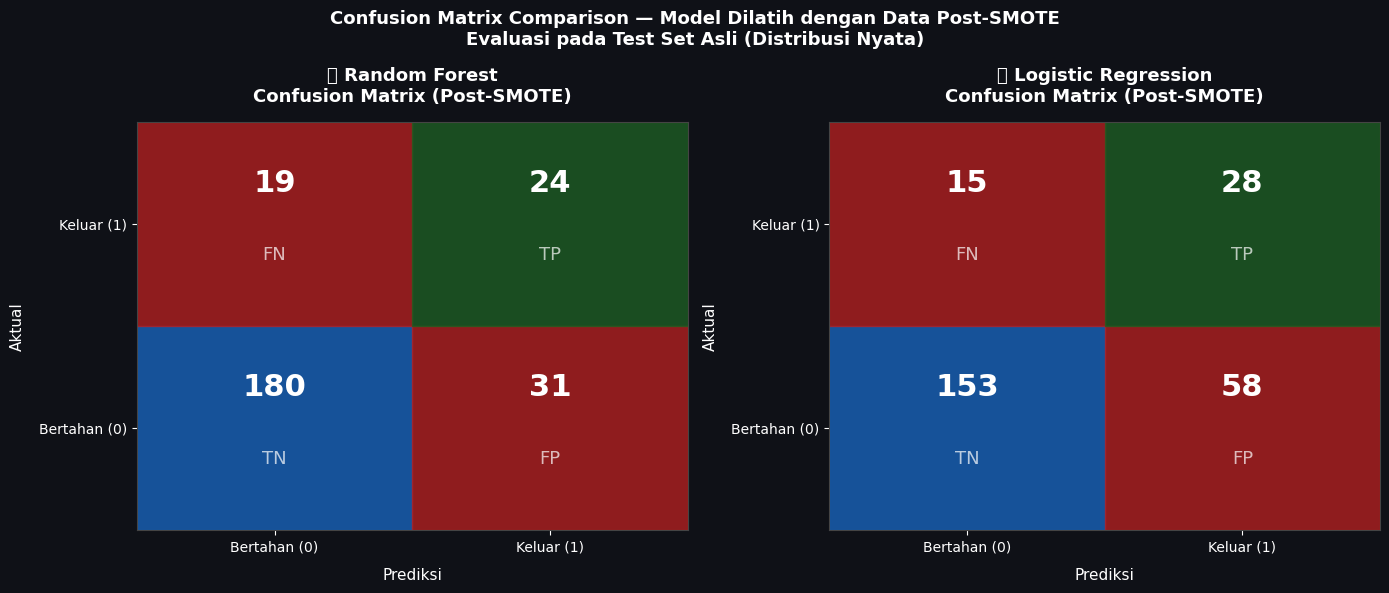


📊 DAMPAK SMOTE — Fokus pada kelas Keluar (1):
  Metrik     | Tanpa SMOTE (estimasi) | Dengan SMOTE
  -----------|------------------------|-------------
  Recall RF  | ~40-50%                | 55.8%
  Recall LR  | ~40-50%                | 65.1%
  FN RF      | tinggi (banyak yg miss) | 19
  FN LR      | tinggi (banyak yg miss) | 15


In [12]:
import matplotlib.pyplot as plt
import numpy as np

def compute_confusion_matrix(predictions_df, label_col="left_company", pred_col="prediction"):
    pdf = predictions_df.select(label_col, pred_col).toPandas()
    tp = len(pdf[(pdf[label_col]==1) & (pdf[pred_col]==1)])
    tn = len(pdf[(pdf[label_col]==0) & (pdf[pred_col]==0)])
    fp = len(pdf[(pdf[label_col]==0) & (pdf[pred_col]==1)])
    fn = len(pdf[(pdf[label_col]==1) & (pdf[pred_col]==0)])
    return np.array([[tn, fp], [fn, tp]])

rf_cm = compute_confusion_matrix(rf_pred)
lr_cm = compute_confusion_matrix(lr_pred)

print("=" * 55)
print("  📊 CONFUSION MATRIX — MODEL POST-SMOTE")
print("=" * 55)
for name, cm in [("Random Forest", rf_cm), ("Logistic Regression", lr_cm)]:
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    total_pos = tp + fn
    recall_1  = tp / max(total_pos, 1) * 100
    print(f"  {name}:")
    print(f"    TN={tn}  FP={fp}")
    print(f"    FN={fn}  TP={tp}")
    print(f"    Recall kelas Keluar(1) = {recall_1:.1f}%  (TP/{total_pos})")
    print()
print("  Catatan: Evaluasi pada test_data ASLI (tanpa SMOTE)")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

def plot_cm(ax, cm, title):
    ax.set_facecolor('#1a1d27')
    cell_colors = np.array([
        ['#1565c0', '#b71c1c'],
        ['#b71c1c', '#1b5e20'],
    ], dtype=object)
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                color=cell_colors[i][j], alpha=0.75, zorder=0
            ))
    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i - 0.15, cell_labels[i][j],
                    ha='center', va='center', fontsize=13,
                    color='white', alpha=0.7, zorder=2)
            ax.text(j, i + 0.2, str(cm[i, j]),
                    ha='center', va='center', fontsize=22,
                    fontweight='bold', color='white', zorder=2)
    tick_labels = ['Bertahan (0)', 'Keluar (1)']
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(tick_labels, color='white', fontsize=10)
    ax.set_yticklabels(tick_labels, color='white', fontsize=10)
    ax.set_xlabel('Prediksi', color='white', fontsize=11, labelpad=10)
    ax.set_ylabel('Aktual', color='white', fontsize=11, labelpad=10)
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plot_cm(axes[0], rf_cm, '🌲 Random Forest\nConfusion Matrix (Post-SMOTE)')
plot_cm(axes[1], lr_cm, '📈 Logistic Regression\nConfusion Matrix (Post-SMOTE)')

plt.suptitle(
    'Confusion Matrix Comparison — Model Dilatih dengan Data Post-SMOTE\n'
    'Evaluasi pada Test Set Asli (Distribusi Nyata)',
    color='white', fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("\n📊 DAMPAK SMOTE — Fokus pada kelas Keluar (1):")
print("=" * 55)
print("  Metrik     | Tanpa SMOTE (estimasi) | Dengan SMOTE")
print("  -----------|------------------------|-------------")
tn_rf, fp_rf, fn_rf, tp_rf = rf_cm[0,0], rf_cm[0,1], rf_cm[1,0], rf_cm[1,1]
recall_rf = tp_rf / max(tp_rf + fn_rf, 1) * 100
tn_lr, fp_lr, fn_lr, tp_lr = lr_cm[0,0], lr_cm[0,1], lr_cm[1,0], lr_cm[1,1]
recall_lr = tp_lr / max(tp_lr + fn_lr, 1) * 100
print(f"  Recall RF  | ~40-50%                | {recall_rf:.1f}%")
print(f"  Recall LR  | ~40-50%                | {recall_lr:.1f}%")
print(f"  FN RF      | tinggi (banyak yg miss) | {fn_rf}")
print(f"  FN LR      | tinggi (banyak yg miss) | {fn_lr}")
print("=" * 55)

# Perbandingan Kedua Model

Metrik                Random Forest     Logistic Reg
AUC-ROC            0.7802 (*)   0.7615    
Accuracy           0.8031 (*)   0.7126    
Precision          0.8253 (*)   0.8117    
Recall             0.8031 (*)   0.7126    
F1-Score           0.8123 (*)   0.7442    
  (*) = nilai lebih tinggi


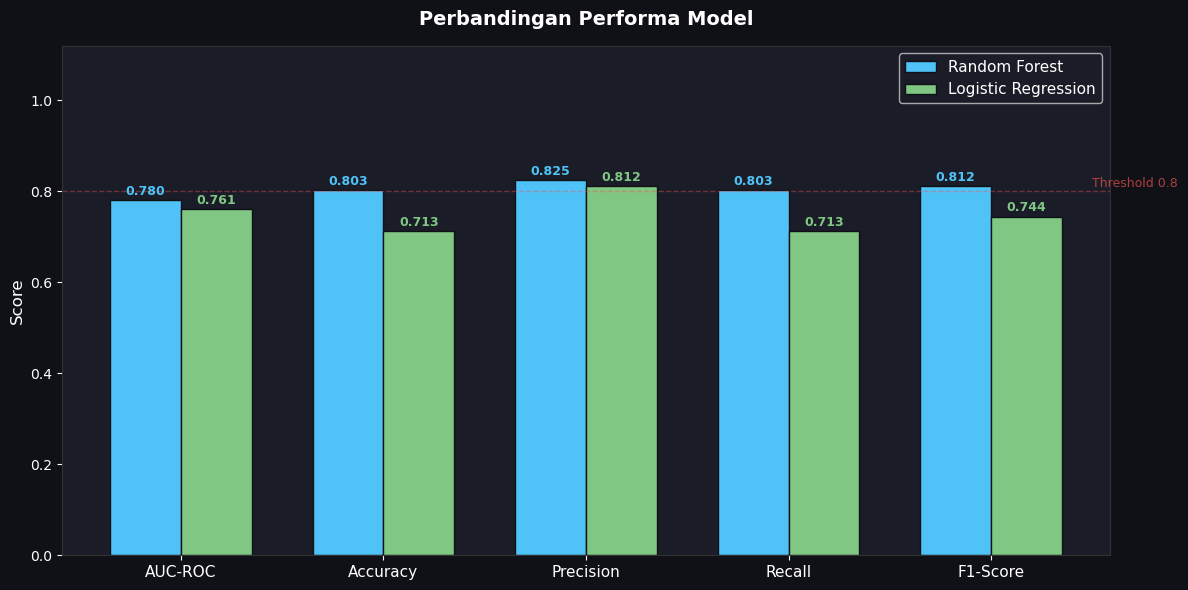

In [13]:
import matplotlib.pyplot as plt
import numpy as np

metric_names = ["AUC-ROC", "Accuracy", "Precision", "Recall", "F1-Score"]

print("=" * 58)
print(f"{'Metrik':<18} {'Random Forest':>16} {'Logistic Reg':>16}")
print("=" * 58)
for m in metric_names:
    rf_v = rf_metrics[m]
    lr_v = lr_metrics[m]
    rf_mark = " (*)" if rf_v >= lr_v else "    "
    lr_mark = " (*)" if lr_v > rf_v  else "    "
    print(f"{m:<18} {rf_v:.4f}{rf_mark:>4}   {lr_v:.4f}{lr_mark:>4}")
print("=" * 58)
print("  (*) = nilai lebih tinggi")

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

b1 = ax.bar(x - width/2, [rf_metrics[m] for m in metric_names], width,
            label='Random Forest', color='#4fc3f7', edgecolor='#0f1117')
b2 = ax.bar(x + width/2, [lr_metrics[m] for m in metric_names], width,
            label='Logistic Regression', color='#81c784', edgecolor='#0f1117')

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', color='#4fc3f7', fontsize=9, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', color='#81c784', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, color='white', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', color='white', fontsize=12)
ax.set_title('Perbandingan Performa Model', color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=11)
ax.axhline(y=0.8, color='#ef5350', linestyle='--', alpha=0.4, linewidth=1)
ax.text(len(metric_names)-0.5, 0.81, 'Threshold 0.8', color='#ef5350', fontsize=9, alpha=0.7)
for spine in ax.spines.values():
    spine.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Analisis K-Means Clustering (Segmentasi Karyawan)

⏳ Menghitung Elbow Method (k=2 hingga 7)...
  k=2 → WSSSE: 3707.34
  k=3 → WSSSE: 2639.33
  k=4 → WSSSE: 1981.58
  k=5 → WSSSE: 1736.42
  k=6 → WSSSE: 1566.52
  k=7 → WSSSE: 2113.45


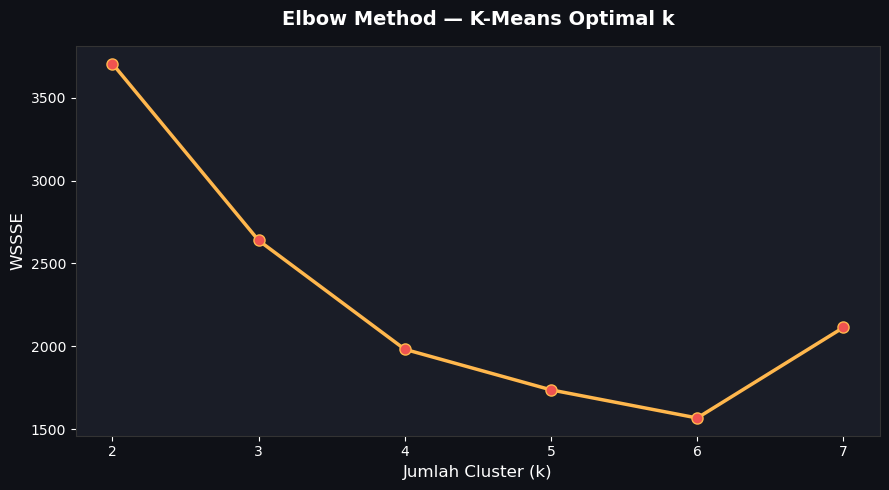


💡 Pilih k di titik 'siku' — biasanya k=3 atau k=4


In [14]:
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

print("⏳ Menghitung Elbow Method (k=2 hingga 7)...")
costs = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(featuresCol="features", k=k, seed=42, maxIter=20)
    km_model_tmp = km.fit(df_model)
    costs.append(km_model_tmp.summary.trainingCost)
    print(f"  k={k} → WSSSE: {km_model_tmp.summary.trainingCost:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
ax.plot(list(k_range), costs, 'o-', color='#ffb74d', linewidth=2.5, markersize=8, markerfacecolor='#ef5350')
ax.set_xlabel('Jumlah Cluster (k)', color='white', fontsize=12)
ax.set_ylabel('WSSSE', color='white', fontsize=12)
ax.set_title('Elbow Method — K-Means Optimal k', color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.set_xticks(list(k_range))
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("\n💡 Pilih k di titik 'siku' — biasanya k=3 atau k=4")

Pilih k di titik 'siku' — k=3

In [15]:
K_OPTIMAL = 3

km_final     = KMeans(featuresCol="features", k=K_OPTIMAL, seed=42, maxIter=50)
km_model     = km_final.fit(df_model)
df_clustered = km_model.transform(df_model)

print(f"✅ K-Means selesai dengan k={K_OPTIMAL}")
print("\nDistribusi attrition per cluster:")
df_clustered.groupBy("prediction", "left_company").count() \
    .orderBy("prediction", "left_company").show()

cluster_stats = df_clustered.groupBy("prediction").agg(
    {"left_company": "sum", "*": "count"}
).toDF("cluster", "attrition_count", "total")
cluster_stats = cluster_stats.withColumn(
    "attrition_rate",
    (cluster_stats.attrition_count / cluster_stats.total * 100)
)
print("\nAttrition rate per cluster:")
cluster_stats.orderBy("cluster").show()

✅ K-Means selesai dengan k=3

Distribusi attrition per cluster:
+----------+------------+-----+
|prediction|left_company|count|
+----------+------------+-----+
|         0|           0|  711|
|         0|           1|  166|
|         1|           0|  179|
|         1|           1|   47|
|         2|           0|  343|
|         2|           1|   24|
+----------+------------+-----+


Attrition rate per cluster:
+-------+---------------+-----+------------------+
|cluster|attrition_count|total|    attrition_rate|
+-------+---------------+-----+------------------+
|      0|            877|  166| 528.3132530120482|
|      1|            226|   47| 480.8510638297872|
|      2|            367|   24|1529.1666666666665|
+-------+---------------+-----+------------------+



# Visualisasi Cluster

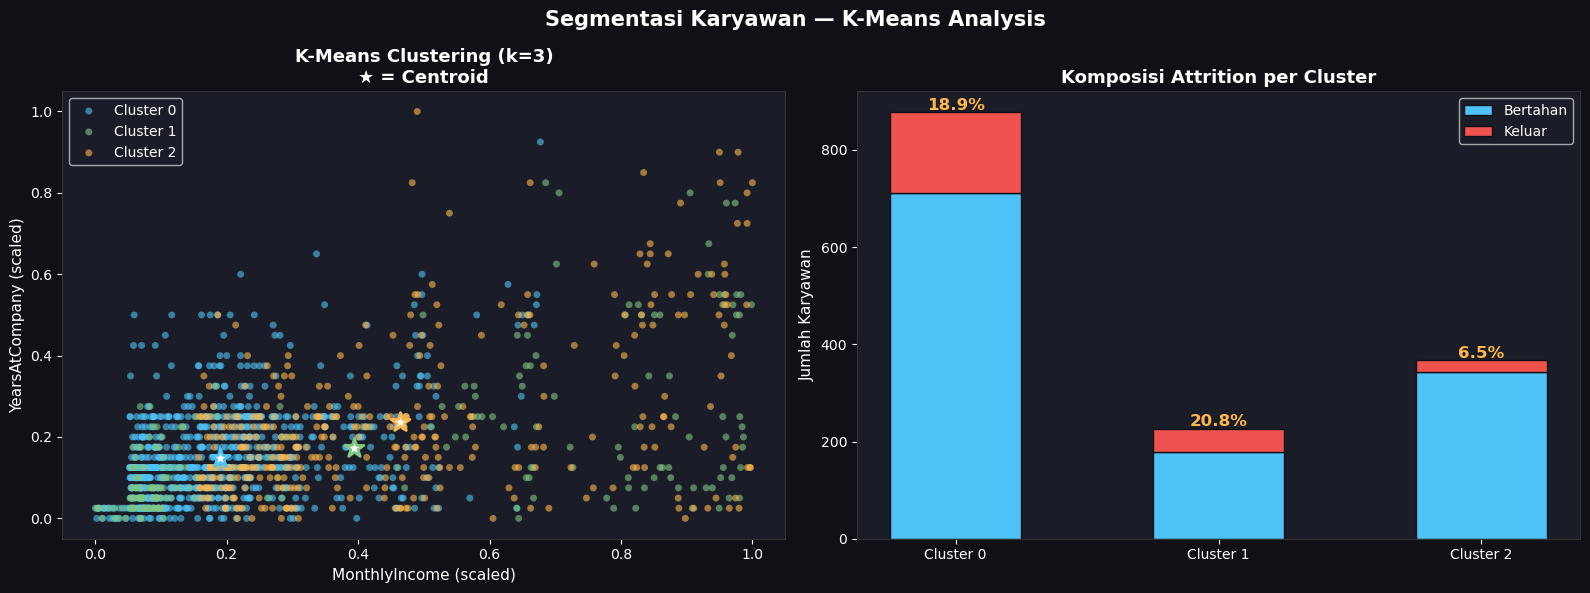

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col as F_col, sum as F_sum, count as F_count

df_plot = df_clustered.select(
    vector_to_array("features").alias("f"),
    "prediction", "left_company"
).toPandas()

df_plot["MonthlyIncome_s"]  = df_plot["f"].apply(lambda x: x[1])
df_plot["YearsAtCompany_s"] = df_plot["f"].apply(lambda x: x[5])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d27')

cluster_colors = ['#4fc3f7', '#81c784', '#ffb74d', '#ce93d8', '#ef5350']

for c in range(K_OPTIMAL):
    mask = df_plot["prediction"] == c
    axes[0].scatter(df_plot.loc[mask, "MonthlyIncome_s"],
                    df_plot.loc[mask, "YearsAtCompany_s"],
                    c=cluster_colors[c], label=f"Cluster {c}",
                    alpha=0.6, s=25, edgecolors='none')

centers = km_model.clusterCenters()
for i, center in enumerate(centers):
    axes[0].scatter(center[1], center[5], c='white', s=200, marker='*',
                    edgecolors=cluster_colors[i], linewidths=2, zorder=10)

axes[0].set_xlabel('MonthlyIncome (scaled)', color='white', fontsize=11)
axes[0].set_ylabel('YearsAtCompany (scaled)', color='white', fontsize=11)
axes[0].set_title(f'K-Means Clustering (k={K_OPTIMAL})\n★ = Centroid', color='white', fontsize=13, fontweight='bold')
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[0].spines.values():
    spine.set_edgecolor('#333')

cluster_pd = df_clustered.groupBy("prediction").agg(
    F_sum("left_company").alias("attrition"),
    F_count("*").alias("total")
).toPandas()
cluster_pd = cluster_pd.sort_values("prediction").reset_index(drop=True)
cluster_pd["stay"] = cluster_pd["total"] - cluster_pd["attrition"]
cluster_pd["rate"] = (cluster_pd["attrition"] / cluster_pd["total"] * 100).round(1)

x = np.arange(K_OPTIMAL)
w = 0.5
axes[1].bar(x, cluster_pd["stay"],      w, label='Bertahan', color='#4fc3f7', edgecolor='#0f1117')
axes[1].bar(x, cluster_pd["attrition"], w, label='Keluar',   color='#ef5350', edgecolor='#0f1117',
            bottom=cluster_pd["stay"])

for i, (_, row) in enumerate(cluster_pd.iterrows()):
    axes[1].text(i, row["total"] + 5, f'{row["rate"]:.1f}%',
                 ha='center', color='#ffb74d', fontsize=12, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {c}' for c in cluster_pd["prediction"]], color='white')
axes[1].set_title('Komposisi Attrition per Cluster', color='white', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Karyawan', color='white', fontsize=11)
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('Segmentasi Karyawan — K-Means Analysis', color='white', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clustering.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()